# Praktikum Supervised Learning

Notebook ini membahas empat metode supervised learning: Linear Regression, Logistic Regression, K-Nearest Neighbors, dan Decision Tree. Semua dataset dibuat praktikum untuk latihan. Nama kolom dataset memakai bahasa Inggris agar sesuai dengan kebiasaan umum pada project data science.

Supervised learning digunakan saat dataset memiliki target. Model belajar dari pasangan fitur dan target, lalu digunakan untuk melakukan prediksi pada data baru.


## Catatan Google Colab

Jika notebook ini dijalankan di Google Colab, siapkan dan upload 4 file CSV supervised berikut saat diminta:

- `house_price_linear.csv`
- `student_pass_logistic.csv`
- `fruit_type_knn.csv`
- `credit_approval_tree.csv`

Jika notebook dijalankan di komputer lokal, file akan dibaca dari folder `data/supervised`.


## Instalasi Library

Jalankan cell ini jika environment belum memiliki library yang dibutuhkan notebook. Cell ini tidak mengubah dataset dan tidak menjalankan training.


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini memeriksa library yang dibutuhkan notebook.

**Alur kode yang perlu dipahami:**
1. Cell ini memeriksa library yang dibutuhkan notebook.
2. Jika ada library yang belum tersedia, cell akan menginstall hanya package yang hilang.
3. Tujuannya agar notebook dapat dijalankan di environment baru tanpa setup manual yang panjang.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Tujuannya agar notebook dapat dijalankan di environment baru tanpa setup manual yang panjang.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


In [ ]:
import importlib.util
import subprocess
import sys
required_packages = [
  ('pandas', 'pandas'),
  ('numpy', 'numpy'),
  ('matplotlib', 'matplotlib'),
  ('seaborn', 'seaborn'),
  ('sklearn', 'scikit-learn'),
  ('gradio', 'gradio'),
]
missing_packages = [pip_name for import_name, pip_name in required_packages if
importlib.util.find_spec(import_name) is None]
if missing_packages:
  print("Menginstall package yang belum tersedia:", missing_packages)
  subprocess.check_call([sys.executable, "-m", "pip", "install",
  *missing_packages])
else:
  print("Semua package yang dibutuhkan sudah tersedia.")

Semua package yang dibutuhkan sudah tersedia.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Jika muncul pesan bahwa semua package sudah tersedia, berarti environment siap dipakai dan tidak ada proses instalasi tambahan.
- Jika muncul daftar package yang diinstall, tunggu sampai proses selesai sebelum lanjut ke cell berikutnya.
- Jika proses install gagal, biasanya penyebabnya koneksi internet, package belum kompatibel, atau runtime perlu direstart.


## Ringkasan Alur Notebook

Setiap model dibahas dengan alur lengkap: penjelasan masalah, load dataset, data understanding, exploratory data analysis, preprocessing, baseline sederhana, training model, evaluasi, visualisasi, interpretasi, contoh prediksi, dan kesimpulan kecil.


In [ ]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
  accuracy_score,
  classification_report,
  confusion_matrix,
  mean_absolute_error,
  mean_squared_error,
  r2_score,
  roc_auc_score,
  RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
sns.set_theme(style="whitegrid")
DATA_DIR = Path("data") / "supervised"
RANDOM_STATE = 42

<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini mengimpor library utama untuk analisis data, visualisasi, dan machine learning.

**Alur kode yang perlu dipahami:**
1. Cell ini mengimpor library utama untuk analisis data, visualisasi, dan machine learning.
2. `DATA_DIR` menentukan lokasi dataset supervised, sedangkan `RANDOM_STATE` membuat hasil eksperimen lebih konsisten.
3. Bagian warning disembunyikan agar output notebook lebih rapi untuk pembelajaran.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Bagian warning disembunyikan agar output notebook lebih rapi untuk pembelajaran.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Cell import yang berhasil biasanya tidak menampilkan output apa pun. Itu normal dan berarti semua library berhasil dimuat.
- Jika muncul error `ModuleNotFoundError`, jalankan kembali cell instalasi library sebelumnya.
- Variabel seperti `DATA_DIR` dan `RANDOM_STATE` akan dipakai oleh cell-cell berikutnya, jadi cell ini tetap wajib dijalankan walaupun outputnya kosong.


## Helper Function

Helper berikut dipakai agar proses evaluasi dan pengecekan data tidak ditulis berulang terlalu banyak. Pada project yang lebih besar, fungsi seperti ini bisa dipindahkan ke file Python terpisah.


In [ ]:
def show_basic_check(df, target_column=None):
  print("Ukuran dataset:", df.shape)
  print("\nJumlah missing value per kolom:")
  display(df.isna().sum().to_frame("missing_count"))
  print("\nContoh data:")
  display(df.head())
  print("\nStatistik deskriptif:")
  display(df.describe(include="all").T)
  if target_column is not None:
    print(f"\nDistribusi target: {target_column}")
    display(df[target_column].value_counts().to_frame("count"))

def regression_metrics(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  return pd.DataFrame(
    {"metric": ["MAE", "RMSE", "R2"], "value": [mae, rmse, r2]}
)

def plot_confusion(y_true, y_pred, labels, title):
  cm = confusion_matrix(y_true, y_pred, labels=labels)
  plt.figure(figsize=(5, 4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels,
yticklabels=labels)
  plt.title(title)
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.tight_layout()
  plt.show()

<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini membuat helper function agar kode evaluasi tidak ditulis berulang-ulang.

**Alur kode yang perlu dipahami:**
1. Cell ini membuat helper function agar kode evaluasi tidak ditulis berulang-ulang.
2. `show_basic_check` dipakai untuk mengecek ukuran data, missing value, contoh baris, statistik, dan distribusi target.
3. Fungsi metrik dan confusion matrix membuat setiap model dievaluasi dengan pola yang konsisten.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Fungsi metrik dan confusion matrix membuat setiap model dievaluasi dengan pola yang konsisten.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Cell ini hanya mendefinisikan fungsi bantu, sehingga output kosong adalah hal yang wajar.
- Fungsi yang dibuat di sini baru terlihat hasilnya ketika dipanggil pada cell analisis berikutnya.
- Jika cell ini error, cell berikutnya yang memanggil fungsi tersebut juga akan gagal, jadi pastikan cell ini berjalan tanpa error.


## Load Semua Dataset

Bagian ini memastikan semua dataset tersedia dan masing-masing berisi 100 baris.


In [ ]:
EXPECTED_CSV_FILES = [
    "house_price_linear.csv",
    "student_pass_logistic.csv",
    "fruit_type_knn.csv",
    "credit_approval_tree.csv",
]

UPLOAD_DIR = Path("uploaded_data") / "supervised"

def is_google_colab():
    try:
        import google.colab
        return True
    except Exception:
        return False


def prepare_dataset_files(expected_files, local_data_dir, upload_dir):
    # Jika di Google Colab → upload manual
    if is_google_colab():
        from google.colab import files

        upload_dir.mkdir(parents=True, exist_ok=True)

        print("Silakan upload 4 file CSV supervised berikut:")
        for filename in expected_files:
            print("-", filename)

        uploaded_files = files.upload()

        for filename, content in uploaded_files.items():
            target_path = upload_dir / Path(filename).name
            target_path.write_bytes(content)

        missing_files = [
            filename for filename in expected_files
            if not (upload_dir / filename).exists()
        ]

        if missing_files:
            raise FileNotFoundError(
                "File berikut belum diupload: " + ", ".join(missing_files)
            )

        return {filename: upload_dir / filename for filename in expected_files}

    # Jika lokal → cek folder upload & folder lokal
    dataset_paths = {}

    for filename in expected_files:
        upload_path = upload_dir / filename
        local_path = local_data_dir / filename

        if upload_path.exists():
            dataset_paths[filename] = upload_path
        elif local_path.exists():
            dataset_paths[filename] = local_path
        else:
            raise FileNotFoundError(
                f"File {filename} belum ditemukan. "
                f"Letakkan file di {local_data_dir} "
                f"atau upload melalui Google Colab."
            )

    return dataset_paths

csv_paths = prepare_dataset_files(
    EXPECTED_CSV_FILES,
    DATA_DIR,
    UPLOAD_DIR
)

file_dataset = {
    "Linear Regression": csv_paths["house_price_linear.csv"],
    "Logistic Regression": csv_paths["student_pass_logistic.csv"],
    "KNN": csv_paths["fruit_type_knn.csv"],
    "Decision Tree": csv_paths["credit_approval_tree.csv"],
}

datasets = {
    name: pd.read_csv(path)
    for name, path in file_dataset.items()
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")
    assert df.shape[0] == 100

Silakan upload 4 file CSV supervised berikut:
- house_price_linear.csv
- student_pass_logistic.csv
- fruit_type_knn.csv
- credit_approval_tree.csv


Saving credit_approval_tree.csv to credit_approval_tree.csv
Saving fruit_type_knn.csv to fruit_type_knn.csv
Saving house_price_linear.csv to house_price_linear.csv
Saving student_pass_logistic.csv to student_pass_logistic.csv
Linear Regression: 100 rows, 5 columns
Logistic Regression: 100 rows, 5 columns
KNN: 100 rows, 5 columns
Decision Tree: 100 rows, 6 columns


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini menyiapkan empat file CSV supervised agar notebook bisa berjalan di Google Colab maupun di komputer lokal.

**Alur kode yang perlu dipahami:**
1. Notebook menentukan empat nama file CSV yang wajib tersedia: `house_price_linear.csv`, `student_pass_logistic.csv`, `fruit_type_knn.csv`, dan `credit_approval_tree.csv`.
2. Jika notebook dijalankan di Google Colab, kode akan menampilkan tombol upload dan meminta pengguna mengupload keempat file tersebut.
3. Jika notebook dijalankan lokal, kode akan membaca file dari folder `data/supervised` atau dari folder `uploaded_data/supervised` jika sebelumnya sudah pernah diupload.
4. Setelah path file siap, setiap CSV dibaca dengan `pd.read_csv` dan disimpan ke dictionary `datasets`.
5. Notebook mengecek bahwa setiap dataset memiliki 100 baris sebelum proses model dilanjutkan.

**Output yang perlu diperhatikan:**  
Pastikan output menampilkan empat dataset supervised dan semuanya memiliki `100 rows`. Jika ada file yang belum diupload atau salah nama, notebook akan menampilkan pesan error berisi nama file yang kurang.

**Kenapa cell ini penting:**  
Di Google Colab, file lokal dari komputer tidak otomatis tersedia. Karena itu pengguna perlu upload empat CSV terlebih dahulu agar seluruh proses training dan evaluasi model bisa berjalan.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Di Google Colab, output akan meminta upload empat file CSV. Pastikan nama file sama persis seperti daftar yang ditampilkan.
- Setelah file dibaca, output harus menampilkan setiap dataset dengan `100 rows`. Jika jumlahnya bukan 100, file yang diupload belum sesuai instruksi.
- Jika muncul pesan file belum ditemukan, cek kembali lokasi file atau nama file CSV yang diupload.


# 1. Linear Regression

Tujuan model ini adalah memprediksi `price_million` berdasarkan karakteristik rumah. Karena target berupa angka kontinu, Linear Regression adalah metode awal yang cocok untuk latihan regresi.


In [ ]:
house_df = datasets["Linear Regression"]
show_basic_check(house_df, target_column="price_million")

Ukuran dataset: (100, 5)

Jumlah missing value per kolom:


,missing_count
house_area_m2,0
bedrooms,0
building_age_years,0
distance_to_center_km,0
price_million,0



Contoh data:


,house_area_m2,bedrooms,building_age_years,distance_to_center_km,price_million
0,103.53,3,19,7.98,833.26
1,65.88,3,5,7.35,704.63
2,116.01,5,11,9.35,1181.58
3,121.34,5,19,13.63,984.71
4,40.37,3,11,8.36,489.56



Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
house_area_m2,100.0,93.5925,21.746945,40.37,79.7725,94.94,109.9775,154.97
bedrooms,100.0,3.4200,1.065340,2.00,3.0000,3.00,4.0000,5.00
building_age_years,100.0,17.4400,10.617614,1.00,8.7500,16.00,27.0000,34.00
distance_to_center_km,100.0,7.8615,3.913710,1.00,5.1925,7.60,9.4425,19.62
price_million,100.0,863.3443,180.044002,419.74,731.3550,873.29,1002.8100,1318.36



Distribusi target: price_million


,count
price_million,
833.26,1
704.63,1
1181.58,1
984.71,1
489.56,1
...,...
639.12,1
533.03,1
664.74,1


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini mengambil dataset Linear Regression dan melakukan pengecekan awal.

**Alur kode yang perlu dipahami:**
1. Cell ini mengambil dataset Linear Regression dan melakukan pengecekan awal.
2. Target yang diprediksi adalah `price_million`, yaitu harga rumah dalam juta.
3. Pengecekan awal penting agar kita memahami bentuk data sebelum training model.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Pengecekan awal penting agar kita memahami bentuk data sebelum training model.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Tabel missing value menunjukkan apakah ada data kosong. Nilai ideal untuk praktikum ini adalah 0 pada setiap kolom.
- Tabel contoh data membantu memastikan nama kolom dan isi data sudah sesuai dengan model yang akan dibuat.
- Statistik deskriptif memperlihatkan rentang nilai, rata-rata, dan sebaran data. Gunakan bagian ini untuk memahami karakter dataset sebelum training.


## EDA Linear Regression

Korelasi membantu melihat hubungan awal antar fitur numerik dan target.


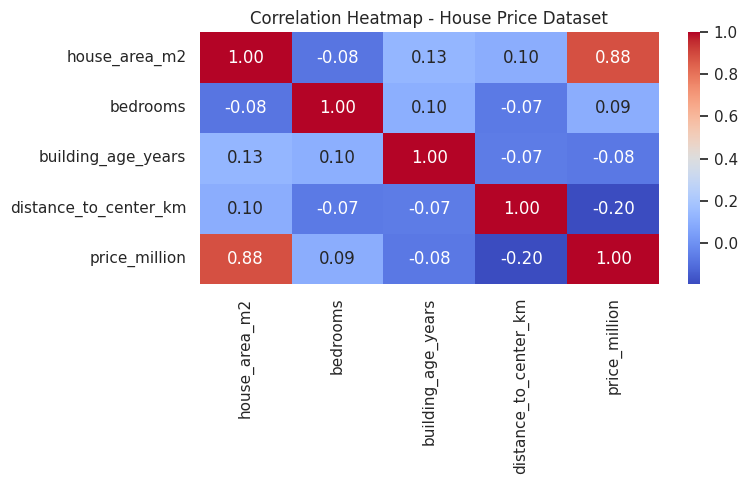

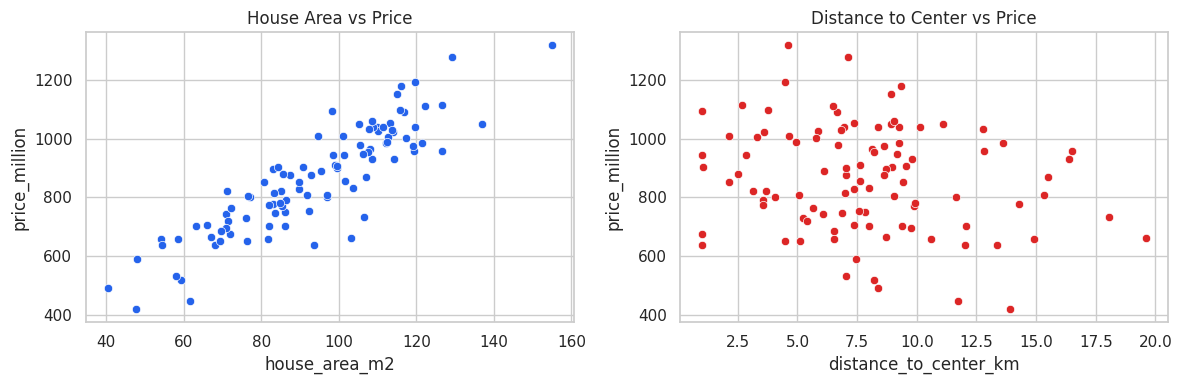

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(house_df.corr(numeric_only=True), annot=True, cmap="coolwarm",
fmt=".2f")
plt.title("Correlation Heatmap - House Price Dataset")
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=house_df, x="house_area_m2", y="price_million",
ax=axes[0], color="#2563eb")
axes[0].set_title("House Area vs Price")
sns.scatterplot(data=house_df, x="distance_to_center_km", y="price_million",
ax=axes[1], color="#dc2626")
axes[1].set_title("Distance to Center vs Price")
plt.tight_layout()
plt.show()

<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini melakukan exploratory data analysis untuk dataset harga rumah.

**Alur kode yang perlu dipahami:**
1. Cell ini melakukan exploratory data analysis untuk dataset harga rumah.
2. Heatmap korelasi menunjukkan hubungan antar fitur numerik dan target.
3. Scatter plot membantu melihat pola hubungan luas rumah dan jarak pusat kota terhadap harga.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Scatter plot membantu melihat pola hubungan luas rumah dan jarak pusat kota terhadap harga.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Angka korelasi mendekati 1 berarti dua fitur cenderung naik bersama, sedangkan mendekati -1 berarti berlawanan arah.
- Warna yang lebih kuat pada heatmap menandakan hubungan yang lebih kuat antar fitur.
- Gunakan heatmap untuk mencari fitur yang tampak berhubungan dengan target atau fitur lain sebelum membuat model.


## Preprocessing, Baseline, dan Training Linear Regression


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini menyiapkan fitur dan target untuk Linear Regression.

**Alur kode yang perlu dipahami:**
1. Cell ini menyiapkan fitur dan target untuk Linear Regression.
2. Data dibagi menjadi train dan test agar evaluasi dilakukan pada data yang belum dilihat model.
3. Baseline rata-rata dipakai sebagai pembanding sederhana sebelum menilai model utama.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Baseline rata-rata dipakai sebagai pembanding sederhana sebelum menilai model utama.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


In [ ]:
linear_features = [
    "house_area_m2",
    "bedrooms",
    "building_age_years",
    "distance_to_center_km",
]

linear_target = "price_million"

X = house_df[linear_features]
y = house_df[linear_target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

baseline_pred = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)

print("Baseline: selalu memprediksi rata-rata harga rumah pada data train.")
display(regression_metrics(y_test, baseline_pred))

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Evaluasi Linear Regression:")
display(regression_metrics(y_test, linear_pred))

Baseline: selalu memprediksi rata-rata harga rumah pada data train.


,metric,value
0,MAE,194.091400
1,RMSE,233.257111
2,R2,-0.130567


Evaluasi Linear Regression:


,metric,value
0,MAE,38.950678
1,RMSE,47.789384
2,R2,0.952544


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Metrik baseline menunjukkan performa tebakan paling sederhana, yaitu selalu memprediksi rata-rata harga pada data train.
- MAE dan RMSE semakin kecil berarti prediksi semakin dekat dengan nilai aktual.
- R2 semakin mendekati 1 berarti model semakin baik menjelaskan variasi target harga.


## Evaluasi dan Visualisasi Linear Regression


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini membandingkan harga aktual, prediksi, dan residual model Linear Regression.

**Alur kode yang perlu dipahami:**
1. Cell ini membandingkan harga aktual, prediksi, dan residual model Linear Regression.
2. Plot aktual vs prediksi menunjukkan seberapa dekat prediksi dengan nilai sebenarnya.
3. Distribusi residual membantu mengecek apakah error model tersebar wajar atau masih memiliki pola tertentu.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Distribusi residual membantu mengecek apakah error model tersebar wajar atau masih memiliki pola tertentu.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


,actual_price,predicted_price,residual
0,904.78,851.16,53.62
1,704.02,682.63,21.39
2,519.23,513.57,5.66
3,1008.67,1003.53,5.14
4,1095.23,1079.61,15.62
5,1052.59,1037.98,14.61
6,1280.35,1234.40,45.95
7,1032.01,953.60,78.41
8,1192.44,1164.84,27.60
9,833.26,918.63,-85.37


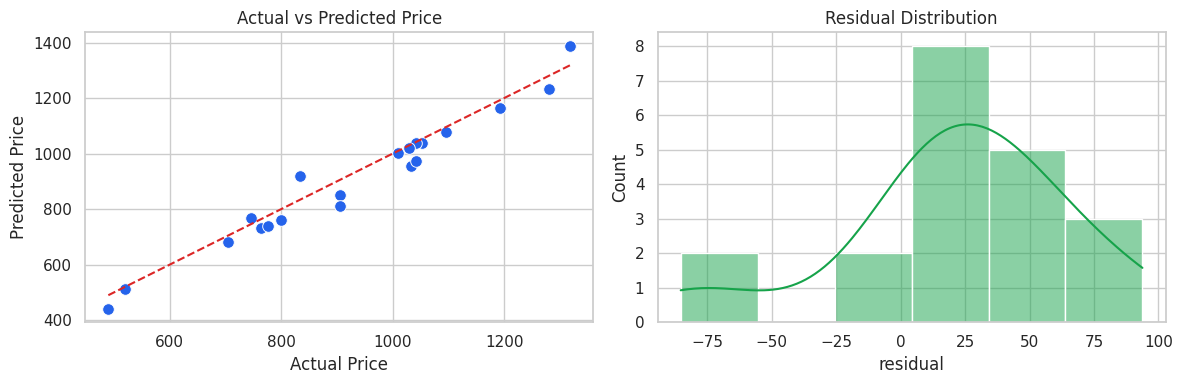

Koefisien model setelah fitur distandardisasi:


,feature,coefficient
0,house_area_m2,165.079736
3,distance_to_center_km,-55.482965
2,building_age_years,-42.496634
1,bedrooms,31.705481


Contoh prediksi harga rumah baru: 1150.80 juta


In [ ]:
linear_result = pd.DataFrame({
    "actual_price": y_test.values,
    "predicted_price": linear_pred.round(2),
    "residual": (y_test.values - linear_pred).round(2),
})

display(linear_result.head(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    x=y_test,
    y=linear_pred,
    ax=axes[0],
    color="#2563eb",
    s=70
)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="#dc2626",
    linestyle="--"
)

axes[0].set_title("Actual vs Predicted Price")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")

sns.histplot(
    linear_result["residual"],
    kde=True,
    ax=axes[1],
    color="#16a34a"
)

axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

linear_coef = pd.DataFrame({
    "feature": linear_features,
    "coefficient": linear_model.named_steps["model"].coef_,
}).sort_values("coefficient", key=abs, ascending=False)

print("Koefisien model setelah fitur distandardisasi:")
display(linear_coef)

new_house = pd.DataFrame([{
    "house_area_m2": 120,
    "bedrooms": 4,
    "building_age_years": 8,
    "distance_to_center_km": 6,
}])

predicted_price = linear_model.predict(new_house)[0]

print(f"Contoh prediksi harga rumah baru: {predicted_price:.2f} juta")

<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Setiap titik pada scatter plot mewakili satu baris data.
- Jika titik membentuk pola naik, turun, atau kelompok tertentu, pola itu dapat membantu menjelaskan perilaku model.
- Jika titik tersebar sangat acak, hubungan antar fitur mungkin lemah atau membutuhkan metode lain untuk dianalisis.


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini membaca koefisien Linear Regression untuk interpretasi fitur.

**Alur kode yang perlu dipahami:**
1. Cell ini membaca koefisien Linear Regression untuk interpretasi fitur.
2. Koefisien membantu melihat fitur mana yang paling memengaruhi prediksi setelah scaling.
3. Contoh prediksi rumah baru menunjukkan cara memakai model pada data input baru.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Contoh prediksi rumah baru menunjukkan cara memakai model pada data input baru.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Tabel koefisien menunjukkan arah dan besar pengaruh fitur setelah data discaling.
- Koefisien positif berarti fitur cenderung menaikkan prediksi, sedangkan koefisien negatif cenderung menurunkannya.
- Hasil contoh prediksi rumah baru menunjukkan bagaimana model dipakai setelah selesai dilatih.


**Interpretasi Linear Regression:** model membaca hubungan linear antara fitur dan harga. Luas rumah biasanya menaikkan harga, sedangkan umur bangunan dan jarak dari pusat kota cenderung menurunkan harga. Residual membantu melihat apakah masih ada pola error yang belum tertangkap model.


# 2. Logistic Regression

Tujuan model ini adalah memprediksi apakah siswa `passed` atau tidak. Target hanya memiliki dua kelas, sehingga Logistic Regression cocok digunakan sebagai model klasifikasi biner.


In [ ]:
student_df = datasets["Logistic Regression"]
show_basic_check(student_df, target_column="passed")

Ukuran dataset: (100, 5)

Jumlah missing value per kolom:


,missing_count
study_hours_per_day,0
attendance_rate,0
assignment_score,0
tutoring,0
passed,0



Contoh data:


,study_hours_per_day,attendance_rate,assignment_score,tutoring,passed
0,5.45,54.11,77.14,1,1
1,3.23,60.06,50.93,0,1
2,4.18,94.37,80.70,0,1
3,4.85,88.74,66.49,1,1
4,5.98,69.37,90.57,1,1



Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
study_hours_per_day,100.0,4.4789,1.731483,0.50,3.3875,4.425,5.4750,9.0
attendance_rate,100.0,76.5807,12.358246,45.00,67.8000,76.520,84.9225,100.0
assignment_score,100.0,72.3646,13.435416,40.66,64.4975,71.785,81.0000,100.0
tutoring,100.0,0.3600,0.482418,0.00,0.0000,0.000,1.0000,1.0
passed,100.0,0.7300,0.446196,0.00,0.0000,1.000,1.0000,1.0



Distribusi target: passed


,count
passed,
1,73
0,27


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini memuat dataset Logistic Regression untuk prediksi kelulusan siswa.

**Alur kode yang perlu dipahami:**
1. Cell ini memuat dataset Logistic Regression untuk prediksi kelulusan siswa.
2. Target `passed` berisi kelas 0 dan 1 sehingga cocok untuk klasifikasi biner.
3. Pengecekan distribusi target membantu melihat apakah kelas cukup seimbang.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Pengecekan distribusi target membantu melihat apakah kelas cukup seimbang.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Tabel missing value menunjukkan apakah ada data kosong. Nilai ideal untuk praktikum ini adalah 0 pada setiap kolom.
- Tabel contoh data membantu memastikan nama kolom dan isi data sudah sesuai dengan model yang akan dibuat.
- Statistik deskriptif memperlihatkan rentang nilai, rata-rata, dan sebaran data. Gunakan bagian ini untuk memahami karakter dataset sebelum training.


## EDA Logistic Regression

Kita melihat distribusi target dan hubungan fitur utama terhadap status kelulusan.


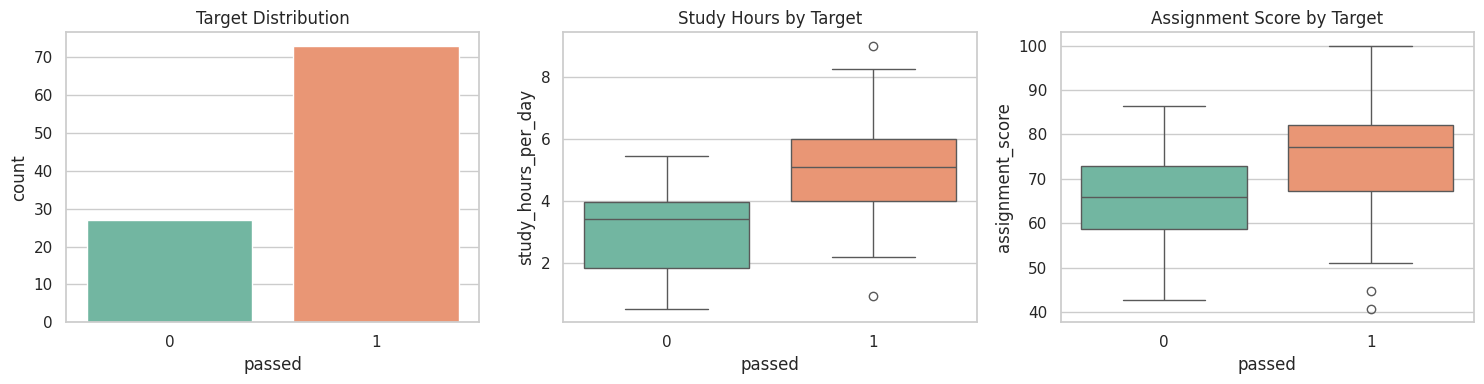

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=student_df, x="passed", ax=axes[0], palette="Set2")
axes[0].set_title("Target Distribution")
sns.boxplot(data=student_df, x="passed", y="study_hours_per_day", ax=axes[1],
palette="Set2")
axes[1].set_title("Study Hours by Target")
sns.boxplot(data=student_df, x="passed", y="assignment_score", ax=axes[2],
palette="Set2")
axes[2].set_title("Assignment Score by Target")
plt.tight_layout()
plt.show()

<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini melakukan EDA untuk kasus kelulusan siswa.

**Alur kode yang perlu dipahami:**
1. Cell ini melakukan EDA untuk kasus kelulusan siswa.
2. Count plot menunjukkan jumlah data pada setiap kelas target.
3. Boxplot membantu membandingkan jam belajar dan nilai tugas antara siswa yang lulus dan tidak lulus.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Boxplot membantu membandingkan jam belajar dan nilai tugas antara siswa yang lulus dan tidak lulus.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Boxplot membantu membandingkan jam belajar dan nilai tugas antara siswa yang lulus dan tidak lulus.
- Cek apakah output sesuai dengan tujuan cell dan tidak menghasilkan error.
- Gunakan hasil dari cell ini sebagai dasar untuk membaca cell berikutnya.


## Preprocessing, Baseline, dan Training Logistic Regression


In [ ]:
logistic_features = [
    "study_hours_per_day",
    "attendance_rate",
    "assignment_score",
    "tutoring",
]

logistic_target = "passed"

X = student_df[logistic_features]
y = student_df[logistic_target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

majority_class = y_train.mode()[0]

baseline_pred = np.full(
    shape=len(y_test),
    fill_value=majority_class
)

print(f"Baseline: selalu memprediksi kelas mayoritas ({majority_class}).")
print(f"Baseline accuracy: {accuracy_score(y_test, baseline_pred):.3f}")

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE)),
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_proba = logistic_model.predict_proba(X_test)[:, 1]

print(f"Model accuracy: {accuracy_score(y_test, logistic_pred):.3f}")
print(f"ROC AUC: {roc_auc_score(y_test, logistic_proba):.3f}")

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["Not Passed", "Passed"]
    )
)

Baseline: selalu memprediksi kelas mayoritas (1).
Baseline accuracy: 0.750
Model accuracy: 0.750
ROC AUC: 0.827
              precision    recall  f1-score   support

  Not Passed       0.50      0.60      0.55         5
      Passed       0.86      0.80      0.83        15

    accuracy                           0.75        20
   macro avg       0.68      0.70      0.69        20
weighted avg       0.77      0.75      0.76        20



<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini menyiapkan, melatih, dan mengevaluasi Logistic Regression.

**Alur kode yang perlu dipahami:**
1. Cell ini menyiapkan, melatih, dan mengevaluasi Logistic Regression.
2. Scaling dilakukan karena fitur memiliki skala berbeda, misalnya jam belajar dan nilai tugas.
3. Akurasi, classification report, dan ROC AUC digunakan agar evaluasi tidak hanya bergantung pada satu angka.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Akurasi, classification report, dan ROC AUC digunakan agar evaluasi tidak hanya bergantung pada satu angka.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Accuracy menunjukkan persentase prediksi yang benar dari seluruh data test.
- Precision menjawab: dari semua yang diprediksi sebagai kelas tertentu, berapa yang benar.
- Recall menjawab: dari semua data yang sebenarnya kelas tertentu, berapa yang berhasil ditemukan model.


## Evaluasi dan Visualisasi Logistic Regression


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini menampilkan confusion matrix dan ROC curve untuk Logistic Regression.

**Alur kode yang perlu dipahami:**
1. Cell ini menampilkan confusion matrix dan ROC curve untuk Logistic Regression.
2. Confusion matrix memperlihatkan jumlah prediksi benar dan salah pada tiap kelas.
3. Koefisien model membantu menjelaskan fitur mana yang meningkatkan atau menurunkan peluang lulus.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Koefisien model membantu menjelaskan fitur mana yang meningkatkan atau menurunkan peluang lulus.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


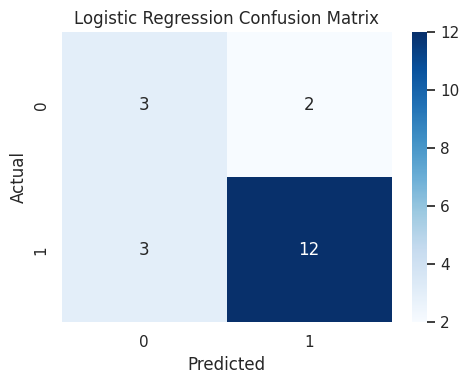

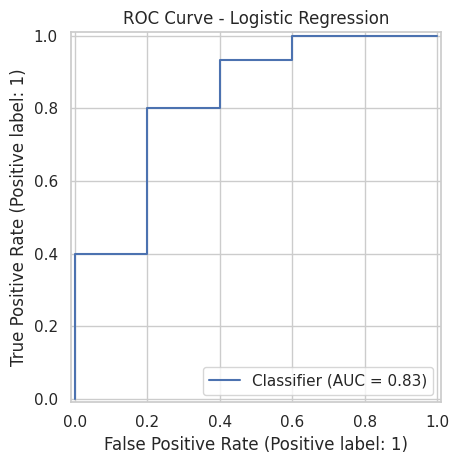

,feature,coefficient
0,study_hours_per_day,1.366959
3,tutoring,0.927825
1,attendance_rate,0.460437
2,assignment_score,0.289392


Contoh prediksi siswa baru: 1 dengan probabilitas lulus 99.36%


In [ ]:
plot_confusion(
    y_test,
    logistic_pred,
    labels=[0, 1],
    title="Logistic Regression Confusion Matrix"
)

RocCurveDisplay.from_predictions(y_test, logistic_proba)

plt.title("ROC Curve - Logistic Regression")
plt.tight_layout()
plt.show()

logistic_coef = pd.DataFrame({
    "feature": logistic_features,
    "coefficient": logistic_model.named_steps["model"].coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)

display(logistic_coef)

new_student = pd.DataFrame([{
    "study_hours_per_day": 6.5,
    "attendance_rate": 88,
    "assignment_score": 82,
    "tutoring": 1,
}])

pass_probability = logistic_model.predict_proba(new_student)[0, 1]
pass_prediction = logistic_model.predict(new_student)[0]

print(
    f"Contoh prediksi siswa baru: {pass_prediction} "
    f"dengan probabilitas lulus {pass_probability:.2%}"
)

<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Confusion matrix dibaca dari perbandingan label aktual dan prediksi. Angka pada diagonal utama adalah prediksi yang benar.
- ROC curve yang semakin dekat ke kiri atas menunjukkan kemampuan pemisahan kelas yang semakin baik.
- Tabel koefisien membantu melihat fitur mana yang paling memengaruhi peluang siswa lulus.


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini memberi contoh prediksi untuk satu siswa baru.

**Alur kode yang perlu dipahami:**
1. Cell ini memberi contoh prediksi untuk satu siswa baru.
2. Input dibuat sebagai DataFrame dengan nama kolom yang sama seperti saat training.
3. Output berupa label prediksi dan probabilitas agar keputusan model lebih mudah dipahami.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Output berupa label prediksi dan probabilitas agar keputusan model lebih mudah dipahami.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Output label menunjukkan prediksi akhir model untuk siswa baru.
- Probabilitas lulus membantu membaca tingkat keyakinan model, bukan hanya keputusan 0 atau 1.
- Jika probabilitas mendekati 50%, keputusan model relatif kurang yakin dibanding probabilitas yang sangat tinggi atau rendah.


**Interpretasi Logistic Regression:** koefisien positif berarti fitur tersebut meningkatkan peluang lulus, sedangkan koefisien negatif menurunkan peluang. Probabilitas prediksi penting karena guru atau analis dapat membuat keputusan berdasarkan tingkat keyakinan, bukan hanya label akhir.


# 3. K-Nearest Neighbors

KNN mengklasifikasikan data berdasarkan kemiripan jarak dengan data latih. Dataset buah cocok untuk contoh ini karena fitur fisik buah dapat membentuk kelompok yang relatif berbeda.


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini memuat dataset KNN untuk klasifikasi jenis buah.

**Alur kode yang perlu dipahami:**
1. Cell ini memuat dataset KNN untuk klasifikasi jenis buah.
2. Target `fruit_type` berisi beberapa kelas buah sehingga ini adalah klasifikasi multikelas.
3. Pengecekan awal membantu memastikan fitur numerik dan label sudah siap digunakan.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Pengecekan awal membantu memastikan fitur numerik dan label sudah siap digunakan.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


In [ ]:
fruit_df = datasets["KNN"]
show_basic_check(fruit_df, target_column="fruit_type")

Ukuran dataset: (100, 5)

Jumlah missing value per kolom:


,missing_count
weight_gram,0
diameter_cm,0
sweetness_brix,0
acidity_ph,0
fruit_type,0



Contoh data:


,weight_gram,diameter_cm,sweetness_brix,acidity_ph,fruit_type
0,137.67,7.54,15.14,3.03,Apple
1,124.91,6.45,11.32,3.00,Orange
2,152.01,8.15,13.30,3.60,Apple
3,150.82,7.33,13.51,3.61,Apple
4,198.31,8.52,12.94,4.03,Pear



Statistik deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
weight_gram,100.0,NaN,NaN,NaN,154.0719,26.201836,85.55,133.66,153.63,173.885,215.07
diameter_cm,100.0,NaN,NaN,NaN,7.2377,0.624482,5.66,6.6975,7.125,7.685,8.92
sweetness_brix,100.0,NaN,NaN,NaN,12.3166,1.512812,9.02,11.315,12.145,13.3,16.45
acidity_ph,100.0,NaN,NaN,NaN,3.527,0.407073,2.57,3.1775,3.575,3.8625,4.3
fruit_type,100,3,Apple,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Distribusi target: fruit_type


,count
fruit_type,
Apple,34
Orange,33
Pear,33


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Tabel missing value menunjukkan apakah ada data kosong. Nilai ideal untuk praktikum ini adalah 0 pada setiap kolom.
- Tabel contoh data membantu memastikan nama kolom dan isi data sudah sesuai dengan model yang akan dibuat.
- Statistik deskriptif memperlihatkan rentang nilai, rata-rata, dan sebaran data. Gunakan bagian ini untuk memahami karakter dataset sebelum training.


## EDA KNN

Visualisasi sebaran fitur membantu melihat apakah kelas buah cukup terpisah.


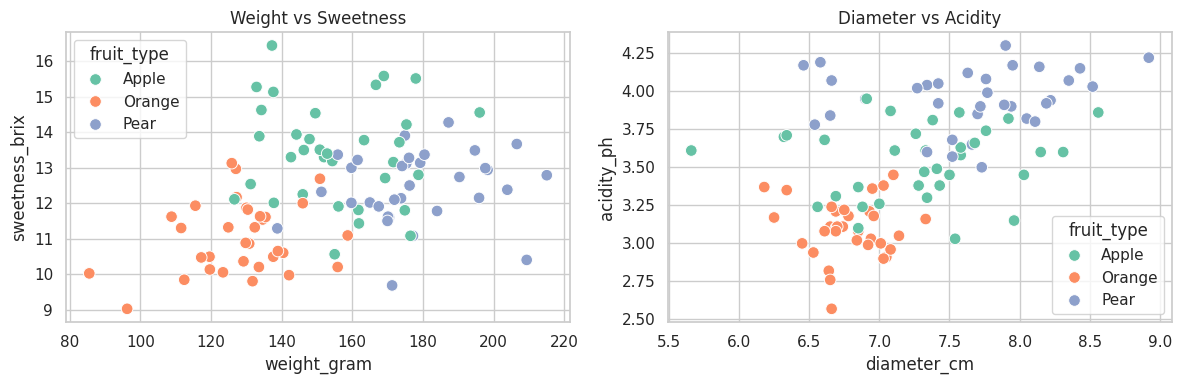

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=fruit_df, x="weight_gram", y="sweetness_brix",

hue="fruit_type", ax=axes[0], palette="Set2", s=70)
axes[0].set_title("Weight vs Sweetness")
sns.scatterplot(data=fruit_df, x="diameter_cm", y="acidity_ph",
hue="fruit_type", ax=axes[1], palette="Set2", s=70)
axes[1].set_title("Diameter vs Acidity")
plt.tight_layout()
plt.show()

<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini memvisualisasikan sebaran fitur buah.

**Alur kode yang perlu dipahami:**
1. Cell ini memvisualisasikan sebaran fitur buah.
2. Scatter plot menunjukkan apakah kelas buah membentuk kelompok yang terpisah.
3. Visualisasi seperti ini penting karena KNN sangat bergantung pada jarak antar data.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Visualisasi seperti ini penting karena KNN sangat bergantung pada jarak antar data.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Setiap titik pada scatter plot mewakili satu baris data.
- Jika titik membentuk pola naik, turun, atau kelompok tertentu, pola itu dapat membantu menjelaskan perilaku model.
- Jika titik tersebar sangat acak, hubungan antar fitur mungkin lemah atau membutuhkan metode lain untuk dianalisis.


## Preprocessing, Tuning K, dan Training KNN


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini mencoba beberapa nilai K untuk K-Nearest Neighbors.

**Alur kode yang perlu dipahami:**
1. Cell ini mencoba beberapa nilai K untuk K-Nearest Neighbors.
2. Nilai K yang berbeda dapat menghasilkan performa yang berbeda karena jumlah tetangga memengaruhi keputusan model.
3. Model akhir memakai K terbaik dari percobaan sederhana pada data test.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Model akhir memakai K terbaik dari percobaan sederhana pada data test.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


In [ ]:
knn_features = ["weight_gram", "diameter_cm", "sweetness_brix", "acidity_ph"]
knn_target = "fruit_type"
X = fruit_df[knn_features]
y = fruit_df[knn_target]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
majority_class = y_train.mode()[0]
baseline_pred = np.full(shape=len(y_test), fill_value=majority_class)
print(f"Baseline accuracy: {accuracy_score(y_test, baseline_pred):.3f}")
k_scores = []
for k in range(1, 16, 2):
    temp_model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=k)),
        ]
    )
    temp_model.fit(X_train, y_train)
    score = temp_model.score(X_test, y_test)
    k_scores.append({"k": k, "accuracy": score})
k_scores_df = pd.DataFrame(k_scores)
display(k_scores_df)
best_k = int(k_scores_df.sort_values(["accuracy", "k"], ascending=[False,
True]).iloc[0]["k"])
print(f"K terbaik dari percobaan sederhana: {best_k}")
knn_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=best_k)),
    ]
)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
print(f"Model accuracy: {accuracy_score(y_test, knn_pred):.3f}")
print(classification_report(y_test, knn_pred))

Baseline accuracy: 0.350


,k,accuracy
0,1,0.80
1,3,0.85
2,5,0.90
3,7,0.90
4,9,0.80
5,11,0.85
6,13,0.85
7,15,0.80


K terbaik dari percobaan sederhana: 5
Model accuracy: 0.900
              precision    recall  f1-score   support

       Apple       1.00      0.71      0.83         7
      Orange       0.88      1.00      0.93         7
        Pear       0.86      1.00      0.92         6

    accuracy                           0.90        20
   macro avg       0.91      0.90      0.90        20
weighted avg       0.91      0.90      0.90        20



<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Tabel nilai K menunjukkan akurasi model untuk beberapa jumlah tetangga.
- K terbaik dipilih dari akurasi tertinggi pada percobaan sederhana ini.
- Classification report menunjukkan performa model pada setiap jenis buah, bukan hanya performa rata-rata.


## Evaluasi dan Visualisasi KNN


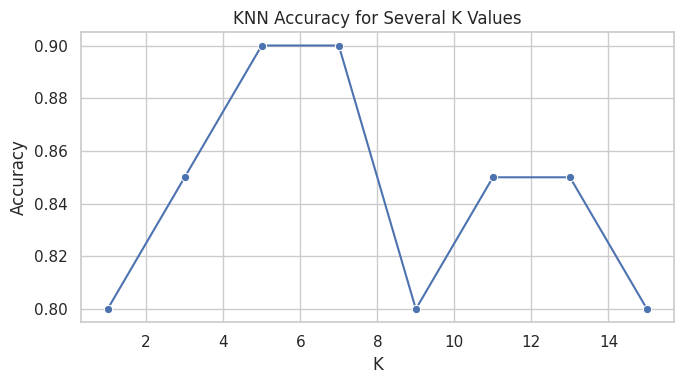

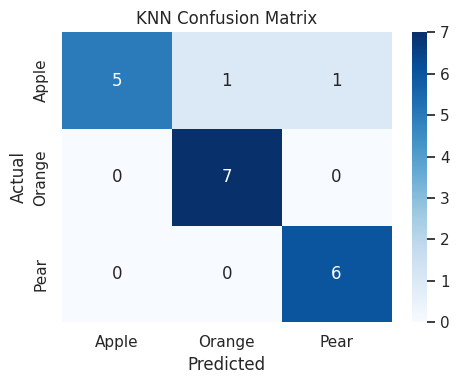

Contoh prediksi buah baru: Apple


,Apple,Orange,Pear
0,0.6,0.4,0.0


In [ ]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=k_scores_df, x="k", y="accuracy", marker="o")
plt.title("KNN Accuracy for Several K Values")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()
plot_confusion(y_test, knn_pred,
labels=sorted(fruit_df["fruit_type"].unique()), title="KNN Confusion Matrix")

new_fruit = pd.DataFrame(
    [{
        "weight_gram": 150,
        "diameter_cm": 7.1,
        "sweetness_brix": 13.2,
        "acidity_ph": 3.4,
    }]
)
fruit_prediction = knn_model.predict(new_fruit)[0]
fruit_probability = pd.DataFrame(
    knn_model.predict_proba(new_fruit),
    columns=knn_model.named_steps["model"].classes_,
)
print(f"Contoh prediksi buah baru: {fruit_prediction}")
display(fruit_probability)

<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini memvisualisasikan akurasi KNN untuk beberapa nilai K.

**Alur kode yang perlu dipahami:**
1. Cell ini memvisualisasikan akurasi KNN untuk beberapa nilai K.
2. Grafik membantu melihat apakah performa stabil atau terlalu bergantung pada satu nilai K.
3. Confusion matrix digunakan untuk melihat kelas buah mana yang paling sering tertukar.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Confusion matrix digunakan untuk melihat kelas buah mana yang paling sering tertukar.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Tabel nilai K menunjukkan akurasi model untuk beberapa jumlah tetangga.
- K terbaik dipilih dari akurasi tertinggi pada percobaan sederhana ini.
- Classification report menunjukkan performa model pada setiap jenis buah, bukan hanya performa rata-rata.


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini mencoba model KNN pada satu data buah baru.

**Alur kode yang perlu dipahami:**
1. Cell ini mencoba model KNN pada satu data buah baru.
2. Probabilitas kelas ditampilkan agar pengguna melihat tingkat keyakinan model untuk setiap jenis buah.
3. Contoh ini bisa dijadikan pola untuk membuat fitur testing pada aplikasi sederhana.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Contoh ini bisa dijadikan pola untuk membuat fitur testing pada aplikasi sederhana.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Output prediksi menunjukkan jenis buah yang dipilih model untuk input baru.
- Tabel probabilitas menunjukkan seberapa kuat model memilih setiap kelas.
- Jika dua probabilitas berdekatan, model melihat input tersebut mirip dengan lebih dari satu jenis buah.


**Interpretasi KNN:** standardisasi penting karena KNN memakai jarak. Tanpa standardisasi, fitur dengan skala besar seperti `weight_gram` dapat mendominasi fitur lain.


# 4. Decision Tree

Decision Tree membuat aturan keputusan bertingkat. Dataset ini memprediksi `approved` berdasarkan profil sederhana calon peminjam.


In [ ]:
credit_df = datasets["Decision Tree"]
show_basic_check(credit_df, target_column="approved")

Ukuran dataset: (100, 6)

Jumlah missing value per kolom:


,missing_count
monthly_income_million,0
age_years,0
dependents,0
credit_score,0
monthly_installment_million,0
approved,0



Contoh data:


,monthly_income_million,age_years,dependents,credit_score,monthly_installment_million,approved
0,8.79,38,0,609,5.31,No
1,10.82,29,3,782,0.62,Yes
2,4.30,36,2,643,2.72,No
3,13.67,37,2,506,1.64,No
4,6.84,44,2,562,2.98,No



Statistik deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
monthly_income_million,100.0,NaN,NaN,NaN,9.7354,3.574835,2.5,7.585,10.21,11.8325,18.99
age_years,100.0,NaN,NaN,NaN,41.07,9.990152,21.0,34.75,41.0,49.0,58.0
dependents,100.0,NaN,NaN,NaN,1.66,1.327411,0.0,1.0,1.0,3.0,4.0
credit_score,100.0,NaN,NaN,NaN,651.76,82.98048,436.0,598.5,654.5,709.25,841.0
monthly_installment_million,100.0,NaN,NaN,NaN,2.2989,1.05611,0.3,1.6925,2.345,2.91,5.31
approved,100,2,No,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Distribusi target: approved


,count
approved,
No,66
Yes,34


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini memuat dataset Decision Tree untuk prediksi kelayakan kredit.

**Alur kode yang perlu dipahami:**
1. Cell ini memuat dataset Decision Tree untuk prediksi kelayakan kredit.
2. Target `approved` berisi label Yes dan No.
3. Data understanding diperlukan agar aturan pohon keputusan dapat diinterpretasikan dengan konteks yang benar.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Data understanding diperlukan agar aturan pohon keputusan dapat diinterpretasikan dengan konteks yang benar.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Tabel missing value menunjukkan apakah ada data kosong. Nilai ideal untuk praktikum ini adalah 0 pada setiap kolom.
- Tabel contoh data membantu memastikan nama kolom dan isi data sudah sesuai dengan model yang akan dibuat.
- Statistik deskriptif memperlihatkan rentang nilai, rata-rata, dan sebaran data. Gunakan bagian ini untuk memahami karakter dataset sebelum training.


## EDA Decision Tree

Kita melihat distribusi target dan beberapa fitur penting seperti credit score dan installment.


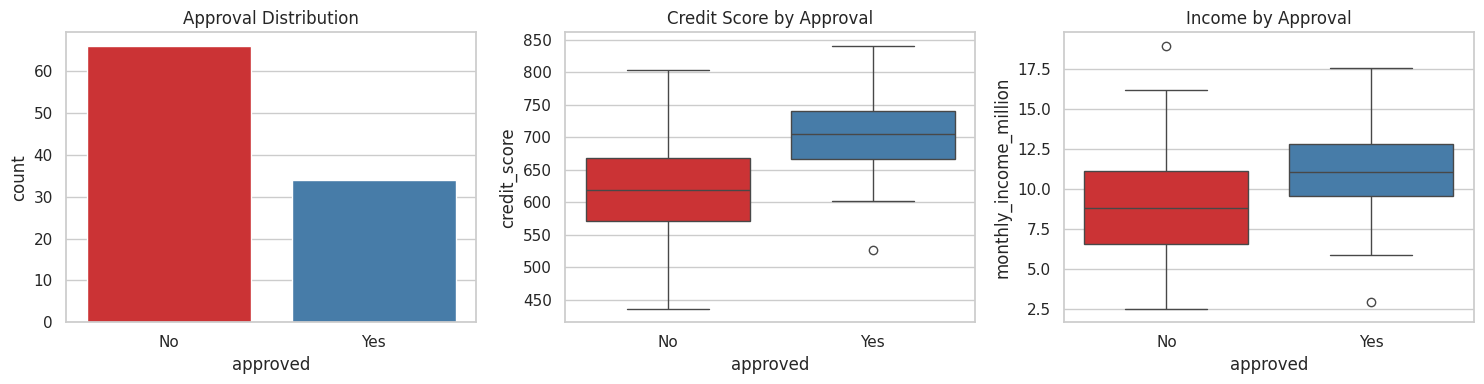

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=credit_df, x="approved", ax=axes[0], palette="Set1")
axes[0].set_title("Approval Distribution")
sns.boxplot(data=credit_df, x="approved", y="credit_score", ax=axes[1],
palette="Set1")
axes[1].set_title("Credit Score by Approval")
sns.boxplot(data=credit_df, x="approved", y="monthly_income_million",
ax=axes[2], palette="Set1")
axes[2].set_title("Income by Approval")
plt.tight_layout()
plt.show()

<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini melakukan EDA pada dataset kredit.

**Alur kode yang perlu dipahami:**
1. Cell ini melakukan EDA pada dataset kredit.
2. Count plot menunjukkan sebaran keputusan kredit.
3. Boxplot membantu melihat perbedaan credit score dan income antara kelas approved dan not approved.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Boxplot membantu melihat perbedaan credit score dan income antara kelas approved dan not approved.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Boxplot membantu melihat perbedaan credit score dan income antara kelas approved dan not approved.
- Cek apakah output sesuai dengan tujuan cell dan tidak menghasilkan error.
- Gunakan hasil dari cell ini sebagai dasar untuk membaca cell berikutnya.


## Preprocessing, Tuning Kedalaman, dan Training Decision Tree


In [ ]:
tree_features = [
    "monthly_income_million",
    "age_years",
    "dependents",
    "credit_score",
    "monthly_installment_million",
]
tree_target = "approved"
X = credit_df[tree_features]
y = credit_df[tree_target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
majority_class = y_train.mode()[0]
baseline_pred = np.full(shape=len(y_test), fill_value=majority_class)
print(f"Baseline accuracy: {accuracy_score(y_test, baseline_pred):.3f}")
depth_scores = []
for depth in range(2, 8):
    temp_tree = DecisionTreeClassifier(max_depth=depth,
random_state=RANDOM_STATE)
    temp_tree.fit(X_train, y_train)
    score = temp_tree.score(X_test, y_test)
    depth_scores.append({"max_depth": depth, "accuracy": score})
depth_scores_df = pd.DataFrame(depth_scores)
display(depth_scores_df)
best_depth = int(depth_scores_df.sort_values(["accuracy", "max_depth"],
ascending=[False, True]).iloc[0]["max_depth"])
print(f"Kedalaman terbaik dari percobaan sederhana: {best_depth}")
tree_model = DecisionTreeClassifier(max_depth=best_depth,
random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
print(f"Model accuracy: {accuracy_score(y_test, tree_pred):.3f}")
print(classification_report(y_test, tree_pred))

Baseline accuracy: 0.650


,max_depth,accuracy
0,2,0.9
1,3,0.9
2,4,0.8
3,5,0.9
4,6,0.9
5,7,0.9


Kedalaman terbaik dari percobaan sederhana: 2
Model accuracy: 0.900
              precision    recall  f1-score   support

          No       0.87      1.00      0.93        13
         Yes       1.00      0.71      0.83         7

    accuracy                           0.90        20
   macro avg       0.93      0.86      0.88        20
weighted avg       0.91      0.90      0.90        20



<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini melatih Decision Tree sambil mencoba beberapa nilai `max_depth`.

**Alur kode yang perlu dipahami:**
1. Cell ini melatih Decision Tree sambil mencoba beberapa nilai `max_depth`.
2. Pembatasan kedalaman penting agar pohon tidak terlalu rumit dan tidak mudah overfitting.
3. Baseline kelas mayoritas tetap dihitung agar performa model bisa dibandingkan dengan tebakan sederhana.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Baseline kelas mayoritas tetap dihitung agar performa model bisa dibandingkan dengan tebakan sederhana.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Tabel `max_depth` menunjukkan akurasi Decision Tree pada beberapa batas kedalaman pohon.
- Depth terbaik dipilih agar model cukup kuat menangkap pola tetapi tidak terlalu rumit.
- Classification report membantu melihat apakah model seimbang dalam memprediksi `Yes` dan `No`.


## Evaluasi dan Visualisasi Decision Tree


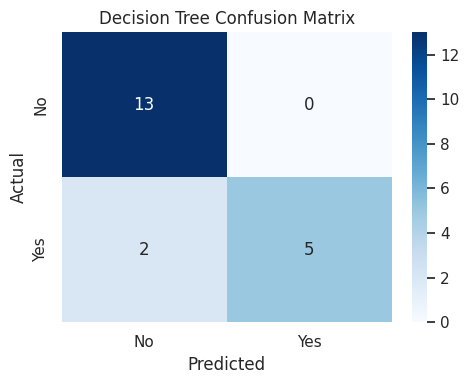

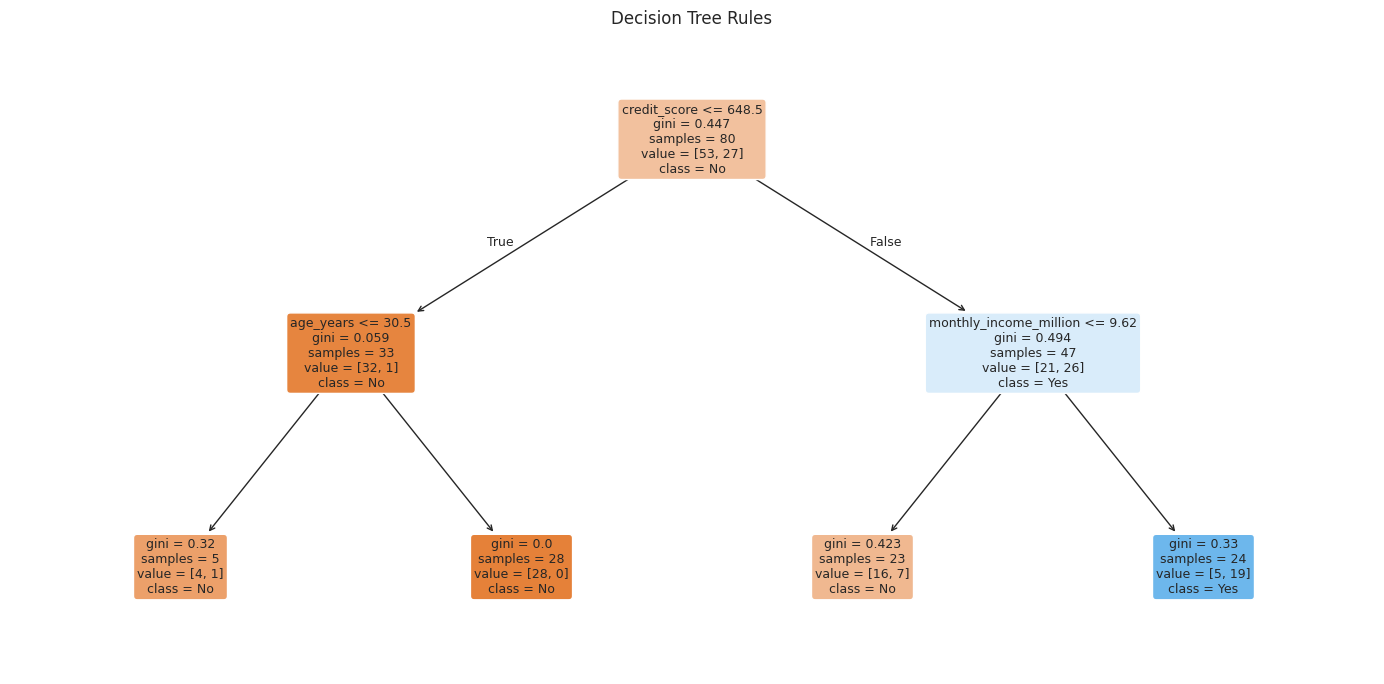

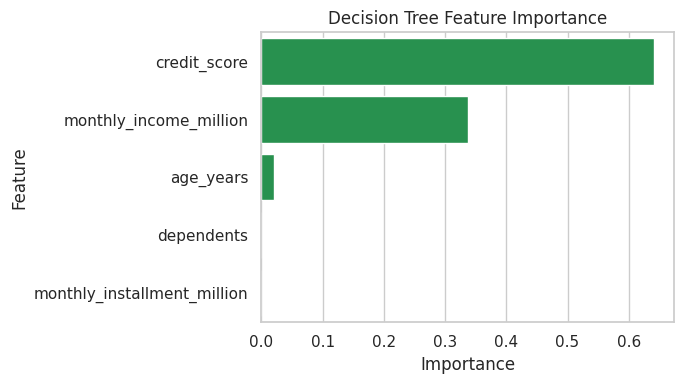

,feature,importance
3,credit_score,0.641772
0,monthly_income_million,0.337682
1,age_years,0.020545
2,dependents,0.000000
4,monthly_installment_million,0.000000


Contoh prediksi calon peminjam baru: Yes


In [ ]:
plot_confusion(
    y_test,
    tree_pred,
    labels=["No", "Yes"],
    title="Decision Tree Confusion Matrix"
)

plt.figure(figsize=(14, 7))

plot_tree(
    tree_model,
    feature_names=tree_features,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
)

plt.title("Decision Tree Rules")
plt.tight_layout()
plt.show()

feature_importance = pd.DataFrame(
    {
        "feature": tree_features,
        "importance": tree_model.feature_importances_,
    }
).sort_values("importance", ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(data=feature_importance, x="importance", y="feature",
color="#16a34a")
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
display(feature_importance)
new_applicant = pd.DataFrame(
    [{
        "monthly_income_million": 10,
        "age_years": 32,
        "dependents": 2,
        "credit_score": 700,
        "monthly_installment_million": 2.2,
    }]
)
approval_prediction = tree_model.predict(new_applicant)[0]
print(f"Contoh prediksi calon peminjam baru: {approval_prediction}")

<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini mengevaluasi Decision Tree dengan confusion matrix dan visualisasi struktur pohon.

**Alur kode yang perlu dipahami:**
1. Cell ini mengevaluasi Decision Tree dengan confusion matrix dan visualisasi struktur pohon.
2. Visualisasi pohon menunjukkan aturan keputusan yang dipakai model.
3. Model seperti ini mudah diajarkan karena alurnya mirip percabangan if-else.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Model seperti ini mudah diajarkan karena alurnya mirip percabangan if-else.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Confusion matrix menunjukkan jumlah keputusan kredit yang benar dan salah.
- Gambar pohon dibaca dari atas ke bawah: setiap percabangan adalah aturan berdasarkan nilai fitur.
- Daun pohon menunjukkan kelas akhir yang dipilih model setelah melewati beberapa aturan.


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini menghitung feature importance Decision Tree.

**Alur kode yang perlu dipahami:**
1. Cell ini menghitung feature importance Decision Tree.
2. Feature importance menunjukkan fitur yang paling sering membantu model memisahkan kelas.
3. Contoh prediksi calon peminjam baru memperlihatkan cara memakai model setelah training.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Contoh prediksi calon peminjam baru memperlihatkan cara memakai model setelah training.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Grafik feature importance menunjukkan fitur yang paling berperan dalam keputusan model.
- Nilai importance yang lebih besar berarti fitur lebih sering atau lebih kuat dipakai untuk memisahkan kelas.
- Hasil prediksi calon peminjam baru menunjukkan cara menggunakan model untuk kasus baru.


**Interpretasi Decision Tree:** model ini mudah dijelaskan karena menghasilkan aturan. Namun, pohon yang terlalu dalam bisa overfitting. Karena itu kita mencoba beberapa `max_depth` sebelum memilih model akhir.


## Gradio untuk Testing Model

Bagian ini berisi demo Gradio langsung di dalam notebook. Secara default `RUN_GRADIO = False` agar notebook tetap bisa dijalankan penuh tanpa berhenti menunggu server. Jika ingin membuka tampilan testing model, ubah nilainya menjadi `True`, lalu jalankan cell ini.


In [ ]:
RUN_GRADIO = True

if RUN_GRADIO:
    import gradio as gr
    def ui_predict_house(house_area_m2, bedrooms, building_age_years, distance_to_center_km):
        row = pd.DataFrame([{
            "house_area_m2": house_area_m2,
            "bedrooms": bedrooms,
            "building_age_years": building_age_years,
            "distance_to_center_km": distance_to_center_km,
        }])

        prediction = linear_model.predict(row)[0]
        return f"Prediksi harga rumah: {prediction:.2f} juta"


    def ui_predict_student(study_hours_per_day, attendance_rate, assignment_score, tutoring):
        row = pd.DataFrame([{
            "study_hours_per_day": study_hours_per_day,
            "attendance_rate": attendance_rate,
            "assignment_score": assignment_score,
            "tutoring": int(tutoring),
        }])

        probability = logistic_model.predict_proba(row)[0, 1]
        prediction = logistic_model.predict(row)[0]
        label = "Passed" if prediction == 1 else "Not Passed"

        return f"Prediksi: {label}\nProbabilitas passed: {probability:.2%}"


    def ui_predict_fruit(weight_gram, diameter_cm, sweetness_brix, acidity_ph):
        row = pd.DataFrame([{
            "weight_gram": weight_gram,
            "diameter_cm": diameter_cm,
            "sweetness_brix": sweetness_brix,
            "acidity_ph": acidity_ph,
        }])

        prediction = knn_model.predict(row)[0]
        probabilities = knn_model.predict_proba(row)[0]
        classes = knn_model.named_steps["model"].classes_

        detail = "\n".join([
            f"{cls}: {prob:.2%}"
            for cls, prob in zip(classes, probabilities)
        ])

        return f"Prediksi jenis buah: {prediction}\n\nProbabilitas:\n{detail}"


    def ui_predict_credit(monthly_income_million, age_years, dependents, credit_score, monthly_installment_million):
        row = pd.DataFrame([{
            "monthly_income_million": monthly_income_million,
            "age_years": age_years,
            "dependents": dependents,
            "credit_score": credit_score,
            "monthly_installment_million": monthly_installment_million,
        }])

        prediction = tree_model.predict(row)[0]
        probabilities = tree_model.predict_proba(row)[0]

        detail = "\n".join([
            f"{cls}: {prob:.2%}"
            for cls, prob in zip(tree_model.classes_, probabilities)
        ])

        return f"Prediksi kredit: {prediction}\n\nProbabilitas:\n{detail}"

    with gr.Blocks(title="Supervised Learning Model Tester") as supervised_demo:

        gr.Markdown("# Supervised Learning Model Tester")
        gr.Markdown("Gunakan tab berikut untuk mencoba input baru pada model yang sudah dilatih di notebook ini.")

        with gr.Tab("Linear Regression"):
            house_area = gr.Slider(35, 180, value=120, step=1, label="house_area_m2")
            bedrooms_input = gr.Slider(1, 6, value=4, step=1, label="bedrooms")
            building_age = gr.Slider(1, 40, value=8, step=1, label="building_age_years")
            distance_center = gr.Slider(1, 25, value=6, step=0.5, label="distance_to_center_km")

            gr.Interface(
                fn=ui_predict_house,
                inputs=[house_area, bedrooms_input, building_age, distance_center],
                outputs=gr.Textbox(label="Output"),
                flagging_mode="never",
            )

        with gr.Tab("Logistic Regression"):
            study_hours = gr.Slider(0.5, 9, value=6, step=0.1, label="study_hours_per_day")
            attendance = gr.Slider(45, 100, value=86, step=1, label="attendance_rate")
            assignment = gr.Slider(35, 100, value=82, step=1, label="assignment_score")
            tutoring_input = gr.Checkbox(value=True, label="tutoring")

            gr.Interface(
                fn=ui_predict_student,
                inputs=[study_hours, attendance, assignment, tutoring_input],
                outputs=gr.Textbox(label="Output", lines=3),
                flagging_mode="never",
            )

        with gr.Tab("KNN"):
            weight = gr.Slider(80, 230, value=150, step=1, label="weight_gram")
            diameter = gr.Slider(5, 10, value=7.2, step=0.1, label="diameter_cm")
            sweetness = gr.Slider(8, 17, value=13.2, step=0.1, label="sweetness_brix")
            acidity = gr.Slider(2.5, 4.5, value=3.4, step=0.1, label="acidity_ph")

            gr.Interface(
                fn=ui_predict_fruit,
                inputs=[weight, diameter, sweetness, acidity],
                outputs=gr.Textbox(label="Output", lines=6),
                flagging_mode="never",
            )

        with gr.Tab("Decision Tree"):
            income = gr.Slider(2, 25, value=10, step=0.1, label="monthly_income_million")
            age = gr.Slider(18, 65, value=32, step=1, label="age_years")
            dependents_input = gr.Slider(0, 6, value=2, step=1, label="dependents")
            credit = gr.Slider(400, 850, value=700, step=1, label="credit_score")
            installment = gr.Slider(0.2, 7, value=2.2, step=0.1, label="monthly_installment_million")

            gr.Interface(
                fn=ui_predict_credit,
                inputs=[income, age, dependents_input, credit, installment],
                outputs=gr.Textbox(label="Output", lines=5),
                flagging_mode="never",
            )

    supervised_demo.launch()

else:
    print(
        "Gradio tidak dijalankan otomatis. "
        "Ubah RUN_GRADIO menjadi True untuk membuka tester model supervised."
    )

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bca997d51556ca1ce7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<!-- PENJELASAN_RINCI_CODE_CELL -->
### Penjelasan Kode

**Tujuan cell:**  
Cell ini berisi demo Gradio opsional untuk menguji model supervised.

**Alur kode yang perlu dipahami:**
1. Cell ini berisi demo Gradio opsional untuk menguji model supervised.
2. `RUN_GRADIO` dibuat False agar notebook tetap bisa dijalankan penuh tanpa membuka server.
3. Jika ingin mencoba UI, ubah nilainya menjadi True setelah semua model di atas sudah dilatih.

**Output yang perlu diperhatikan:**  
Perhatikan output yang muncul setelah cell dijalankan. Output tersebut dipakai untuk mengecek apakah proses pada cell ini berhasil dan apakah hasilnya masuk akal. Pada cell ini, fokus utama pembacaan output adalah: Jika ingin mencoba UI, ubah nilainya menjadi True setelah semua model di atas sudah dilatih.

**Kenapa cell ini penting:**  
Cell ini menjadi bagian dari alur kerja project machine learning yang utuh. Jika cell ini dilewati atau hasilnya tidak dicek, proses berikutnya bisa menghasilkan model, evaluasi, atau visualisasi yang keliru.


<!-- PENJELASAN_OUTPUT_CELL -->
### Penjelasan Output

- Jika `RUN_GRADIO` masih False, output hanya memberi tahu bahwa Gradio tidak dijalankan. Ini normal saat validasi notebook.
- Jika `RUN_GRADIO` diubah menjadi True, output akan menampilkan link atau tampilan Gradio untuk mencoba model.
- Jalankan cell Gradio setelah model selesai dilatih agar fungsi prediksi sudah memiliki model yang siap dipakai.


## Kesimpulan Supervised Learning

Linear Regression cocok untuk prediksi angka, Logistic Regression cocok untuk klasifikasi biner, KNN cocok untuk klasifikasi berbasis kemiripan, dan Decision Tree cocok untuk aturan keputusan yang mudah dijelaskan. Alur yang sama dapat dipakai untuk project lain: pahami masalah, cek data, lakukan EDA, siapkan preprocessing, buat baseline, latih model, evaluasi, visualisasikan hasil, lalu interpretasikan.
